
# Triadic Cell Notebook v23
## Rebalanced bridge world with edge-preserving defrag

This notebook continues directly from v22.

v22 proved:
- separating **Shape / Bridge / Value** is correct
- defragging traces helps representation
- but defrag alone does **not** improve policy accuracy

So v23 changes the world, not just the storage.

## What changes in v23

1. **Rebalanced bridge world**
   - explicit carry-fracture cases
   - explicit wrong-class retire cases
   - explicit borderline provisional cases
   - targeted generation for underrepresented bridge actions

2. **Edge-preserving defrag**
   - core packets are clustered
   - edge packets are preserved
   - boundary cases are not averaged away

3. **Policy comparison on a natural held-out world**
   - imbalanced natural-training head
   - balanced raw-training head
   - balanced edge-preserving defrag head

The head still predicts bridge actions:

- promote
- hold
- retire
- grow_left
- grow_right
- grow_carry

This is still **not** base-model training.
It is runtime training.



## How this maps to actual AI software

This notebook targets the software stack around the model.

- **Foundation model / LLM**
  - unchanged
  - still a proposal engine

- **Shape runtime**
  - packet reading
  - support / hinge / carry / contradiction

- **Bridge policy**
  - the trainable object here
  - decides what the search does next

- **Value layer**
  - late readout only
  - label / decoded answer / report

So this notebook is training the part that sits between proposal and report.


In [1]:

from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(suppress=True, precision=4)

rng = np.random.default_rng(42)

print("Environment ready.")


Environment ready.



## Canonical packet world


In [2]:

prefixes = np.array([
    [1.00, 0.05, 0.05, 0.05],
    [0.05, 1.00, 0.05, 0.05],
    [0.05, 0.05, 1.00, 0.05],
    [0.05, 0.05, 0.05, 1.00],
], dtype=float)

tail_prototypes = np.array([
    [0.92, 0.18, 0.58, 0.22],
    [0.18, 0.90, 0.26, 0.60],
    [0.62, 0.24, 0.90, 0.18],
    [0.22, 0.62, 0.18, 0.88],
], dtype=float)

ACTION_NAMES = ["promote", "hold", "retire", "grow_left", "grow_right", "grow_carry"]
ACTION_TO_ID = {name: i for i, name in enumerate(ACTION_NAMES)}
ID_TO_ACTION = {i: name for name, i in ACTION_TO_ID.items()}

def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    na = np.linalg.norm(a) + 1e-8
    nb = np.linalg.norm(b) + 1e-8
    return float(np.dot(a, b) / (na * nb))

def top2_margin(scores: np.ndarray):
    order = np.argsort(scores)[::-1]
    top1_idx = int(order[0])
    top1 = float(scores[order[0]])
    top2 = float(scores[order[1]]) if len(order) > 1 else 0.0
    return top1_idx, top1, top1 - top2



## Corruption modes

We use two worlds:

### Natural world
What the runtime might see most often.

### Bridge-balanced world
What the bridge head needs in order to learn the full search grammar.


In [3]:

NATURAL_MODES = [
    "clean",
    "missing_left",
    "missing_right",
    "bad_carry",
    "ambiguous",
    "noisy",
    "broken",
]

NATURAL_WEIGHTS = np.array([0.22, 0.14, 0.14, 0.16, 0.12, 0.14, 0.08], dtype=float)
NATURAL_WEIGHTS = NATURAL_WEIGHTS / NATURAL_WEIGHTS.sum()

BALANCED_MODES = [
    "clean",
    "missing_left",
    "missing_right",
    "carry_fracture",
    "bad_carry",
    "ambiguous",
    "noisy",
    "broken",
    "borderline",
    "wrong_class",
]

BALANCED_WEIGHTS = np.array([0.10, 0.14, 0.14, 0.14, 0.14, 0.10, 0.08, 0.06, 0.05, 0.05], dtype=float)
BALANCED_WEIGHTS = BALANCED_WEIGHTS / BALANCED_WEIGHTS.sum()

def corrupt_tail(base_tail: np.ndarray, mode: str, target_slot: int) -> np.ndarray:
    x = base_tail.copy()

    if mode == "clean":
        x += rng.normal(0.0, 0.02, size=x.shape[0])

    elif mode == "missing_left":
        x[0] *= rng.uniform(0.0, 0.18)
        x += rng.normal(0.0, 0.02, size=x.shape[0])

    elif mode == "missing_right":
        x[3] *= rng.uniform(0.0, 0.18)
        x += rng.normal(0.0, 0.02, size=x.shape[0])

    elif mode == "carry_fracture":
        # keep rails and hinge mostly intact, break the carry relation
        x[1] = np.clip(x[1] + rng.uniform(0.35, 0.60), 0.0, 1.0)
        x[2] = np.clip(x[2] + rng.normal(0.0, 0.01), 0.0, 1.0)
        x[0] = np.clip(x[0] + rng.normal(0.0, 0.01), 0.0, 1.0)
        x[3] = np.clip(x[3] + rng.normal(0.0, 0.01), 0.0, 1.0)

    elif mode == "bad_carry":
        x[1] = np.clip(x[1] + rng.uniform(0.22, 0.48), 0.0, 1.0)
        x[2] = np.clip(x[2] - rng.uniform(0.08, 0.22), 0.0, 1.0)
        x += rng.normal(0.0, 0.015, size=x.shape[0])

    elif mode == "ambiguous":
        alt = int((target_slot + rng.integers(1, 4)) % len(tail_prototypes))
        x = 0.52 * base_tail + 0.48 * tail_prototypes[alt] + rng.normal(0.0, 0.02, size=x.shape[0])

    elif mode == "noisy":
        mask = rng.random(x.shape[0]) < 0.25
        x[mask] = 0.0
        x += rng.normal(0.0, 0.05, size=x.shape[0])

    elif mode == "broken":
        x = rng.uniform(0.0, 1.0, size=x.shape[0])

    elif mode == "borderline":
        x = 0.85 * base_tail + 0.15 * np.roll(base_tail, 1) + rng.normal(0.0, 0.025, size=x.shape[0])
        x[0] = np.clip(x[0] - 0.08, 0.0, 1.0)
        x[3] = np.clip(x[3] - 0.08, 0.0, 1.0)

    elif mode == "wrong_class":
        alt = int((target_slot + rng.integers(1, 4)) % len(tail_prototypes))
        x = 0.10 * base_tail + 0.90 * tail_prototypes[alt] + rng.normal(0.0, 0.02, size=x.shape[0])

    return np.clip(x, 0.0, 1.0)



## Shape packet extraction


In [4]:

def packet_shape_features(observed_tail: np.ndarray, candidate_slot: int):
    candidate_tail = tail_prototypes[candidate_slot]
    candidate_prefix = prefixes[candidate_slot]

    left_support = 1.0 - abs(observed_tail[0] - candidate_tail[0])
    hinge_fit = 1.0 - abs(observed_tail[2] - candidate_tail[2])
    right_support = 1.0 - abs(observed_tail[3] - candidate_tail[3])

    carry_target = 0.5 * candidate_tail[1] + 0.5 * candidate_tail[2]
    carry_obs = 0.5 * observed_tail[1] + 0.5 * observed_tail[2]
    carry_fit = 1.0 - abs(carry_obs - carry_target)

    tail_fit = cosine_similarity(observed_tail, candidate_tail)
    prefix_hint = cosine_similarity(observed_tail, candidate_prefix)
    contradiction = 1.0 - prefix_hint

    bilateral = 0.5 * (left_support + right_support)
    support_balance = 1.0 - abs(left_support - right_support)

    return {
        "left_support": float(np.clip(left_support, 0.0, 1.0)),
        "hinge_fit": float(np.clip(hinge_fit, 0.0, 1.0)),
        "right_support": float(np.clip(right_support, 0.0, 1.0)),
        "carry_fit": float(np.clip(carry_fit, 0.0, 1.0)),
        "tail_fit": float(np.clip(tail_fit, 0.0, 1.0)),
        "prefix_hint": float(np.clip(prefix_hint, 0.0, 1.0)),
        "contradiction": float(np.clip(contradiction, 0.0, 1.0)),
        "bilateral": float(np.clip(bilateral, 0.0, 1.0)),
        "support_balance": float(np.clip(support_balance, 0.0, 1.0)),
    }

def value_only_predict(observed_tail: np.ndarray):
    scores = np.array([cosine_similarity(observed_tail, t) for t in tail_prototypes], dtype=float)
    pred_slot, _, margin = top2_margin(scores)
    return pred_slot, float(margin), scores

def packet_gate(shape_features: dict, route_margin: float):
    gate_score = (
        0.18 * shape_features["left_support"]
        + 0.22 * shape_features["hinge_fit"]
        + 0.18 * shape_features["right_support"]
        + 0.14 * shape_features["carry_fit"]
        + 0.12 * shape_features["tail_fit"]
        + 0.10 * shape_features["bilateral"]
        + 0.06 * route_margin
    )
    passes = (
        shape_features["left_support"] > 0.58 and
        shape_features["hinge_fit"] > 0.58 and
        shape_features["right_support"] > 0.58 and
        shape_features["carry_fit"] > 0.58 and
        route_margin > 0.03 and
        gate_score > 0.62
    )
    return float(gate_score), bool(passes)



## Bridge oracle

This is the action law we want the small head to imitate.


In [5]:

def bridge_oracle(pred_slot: int, target_slot: int, shape_features: dict, route_margin: float):
    gate_score, passes = packet_gate(shape_features, route_margin)

    # carry repair comes before promote/retire when the packet is otherwise coherent
    if (
        shape_features["carry_fit"] < 0.72 and
        shape_features["bilateral"] > 0.72 and
        pred_slot == target_slot
    ):
        return "grow_carry", gate_score, passes

    if shape_features["left_support"] < 0.54 and shape_features["right_support"] >= 0.60:
        return "grow_left", gate_score, passes

    if shape_features["right_support"] < 0.54 and shape_features["left_support"] >= 0.60:
        return "grow_right", gate_score, passes

    if pred_slot != target_slot and shape_features["tail_fit"] < 0.84 and route_margin > 0.08:
        return "retire", gate_score, passes

    if shape_features["hinge_fit"] < 0.58 or route_margin < 0.05 or gate_score < 0.60:
        return "hold", gate_score, passes

    if passes and pred_slot == target_slot:
        return "promote", gate_score, passes

    return "hold", gate_score, passes



## World generators


In [6]:

shape_cols = [
    "left_support",
    "hinge_fit",
    "right_support",
    "carry_fit",
    "tail_fit",
    "prefix_hint",
    "contradiction",
    "bilateral",
    "support_balance",
    "value_margin",
    "gate_score",
]

def make_row(target_slot: int, mode: str):
    observed_tail = corrupt_tail(tail_prototypes[target_slot], mode, target_slot)
    pred_slot, value_margin, _ = value_only_predict(observed_tail)
    shape = packet_shape_features(observed_tail, pred_slot)
    action, gate_score, packet_pass = bridge_oracle(pred_slot, target_slot, shape, value_margin)

    row = {
        "target_slot": target_slot,
        "pred_slot": pred_slot,
        "corruption_mode": mode,
        "value_margin": value_margin,
        "gate_score": gate_score,
        "packet_pass": int(packet_pass),
        "action": action,
        "action_id": ACTION_TO_ID[action],
        "value_correct": int(pred_slot == target_slot),
    }
    for k, v in shape.items():
        row[k] = v
    return row

def generate_natural_world(n_per_class: int = 800):
    rows = []
    for target_slot in range(4):
        for _ in range(n_per_class):
            mode = rng.choice(NATURAL_MODES, p=NATURAL_WEIGHTS)
            rows.append(make_row(target_slot, mode))
    return pd.DataFrame(rows)

def targeted_row(action: str, tries: int = 20000):
    action_modes = {
        "promote": ["clean"],
        "hold": ["borderline", "ambiguous", "noisy"],
        "retire": ["wrong_class", "broken"],
        "grow_left": ["missing_left"],
        "grow_right": ["missing_right"],
        "grow_carry": ["carry_fracture"],
    }
    for _ in range(tries):
        target_slot = int(rng.integers(0, 4))
        mode = rng.choice(action_modes[action])
        row = make_row(target_slot, mode)
        if row["action"] == action:
            return row
    return None

def generate_balanced_bridge_world(quota_per_action: int = 600):
    rows = []

    for action in ACTION_NAMES:
        count = 0
        while count < quota_per_action:
            row = targeted_row(action)
            if row is None:
                break
            rows.append(row)
            count += 1

    # add some natural noise so the world is not too synthetic
    extra = generate_natural_world(n_per_class=120)
    rows.extend(extra.to_dict(orient="records"))

    return pd.DataFrame(rows)



## Build worlds


In [7]:

natural_df = generate_natural_world(n_per_class=800)
balanced_df = generate_balanced_bridge_world(quota_per_action=500)

natural_summary = pd.DataFrame([{
    "natural_packets": int(len(natural_df)),
    "natural_value_only_accuracy": float(natural_df["value_correct"].mean()),
    "natural_packet_pass_rate": float(natural_df["packet_pass"].mean()),
    "natural_mean_gate_score": float(natural_df["gate_score"].mean()),
}])

natural_action_mix = (
    natural_df["action"]
    .value_counts(normalize=True)
    .rename_axis("action")
    .reset_index(name="fraction")
)

balanced_action_mix = (
    balanced_df["action"]
    .value_counts(normalize=True)
    .rename_axis("action")
    .reset_index(name="fraction")
)

natural_summary, natural_action_mix, balanced_action_mix


(   natural_packets  natural_value_only_accuracy  natural_packet_pass_rate  \
 0             3200                      0.78125                  0.620625   
 
    natural_mean_gate_score  
 0                 0.848907  ,
        action  fraction
 0     promote  0.534687
 1        hold  0.251875
 2   grow_left  0.100312
 3  grow_right  0.089688
 4  grow_carry  0.016250
 5      retire  0.007188,
        action  fraction
 0     promote  0.221264
 1        hold  0.174425
 2  grow_right  0.157759
 3   grow_left  0.155460
 4  grow_carry  0.146264
 5      retire  0.144828)


## Edge-preserving defrag

Core packets are clustered.
Edge packets are preserved.

This prevents the boundary cases from being averaged away.


In [8]:

def mark_edge_packets(df: pd.DataFrame):
    edge = (
        (df["gate_score"].between(0.58, 0.70)) |
        (df["value_margin"] < 0.08) |
        (df["action"].isin(["hold", "grow_carry", "retire"])) |
        (df["support_balance"] < 0.86)
    )
    out = df.copy()
    out["is_edge"] = edge.astype(int)
    return out

def greedy_defrag_core_only(df: pd.DataFrame, similarity_threshold: float = 0.992):
    canonical_rows = []

    for action in ACTION_NAMES:
        sub = df[(df["action"] == action) & (df["is_edge"] == 0)].reset_index(drop=True)
        if len(sub) == 0:
            continue

        X = sub[shape_cols].to_numpy(dtype=float)
        norms = np.linalg.norm(X, axis=1, keepdims=True) + 1e-8
        Xn = X / norms

        clusters = []

        for i in range(len(sub)):
            x = Xn[i]
            assigned = False

            for cluster in clusters:
                sim = float(np.dot(x, cluster["prototype"]))
                if sim >= similarity_threshold:
                    cluster["members"].append(i)
                    member_idx = cluster["members"]
                    mean_vec = Xn[member_idx].mean(axis=0)
                    cluster["prototype"] = mean_vec / (np.linalg.norm(mean_vec) + 1e-8)
                    assigned = True
                    break

            if not assigned:
                clusters.append({
                    "prototype": x.copy(),
                    "members": [i],
                })

        for cid, cluster in enumerate(clusters):
            member_df = sub.iloc[cluster["members"]]
            row = {col: float(member_df[col].mean()) for col in shape_cols}
            row["action"] = action
            row["action_id"] = ACTION_TO_ID[action]
            row["weight"] = int(len(member_df))
            row["cluster_id"] = cid
            row["is_edge"] = 0
            canonical_rows.append(row)

    return pd.DataFrame(canonical_rows)

balanced_marked = mark_edge_packets(balanced_df)
core_defrag_df = greedy_defrag_core_only(balanced_marked, similarity_threshold=0.992)
edge_keep_df = balanced_marked[balanced_marked["is_edge"] == 1][shape_cols + ["action", "action_id", "is_edge"]].copy()
edge_keep_df["weight"] = 1
edge_keep_df["cluster_id"] = -1

defrag_edge_df = pd.concat([core_defrag_df, edge_keep_df], ignore_index=True)

defrag_summary = pd.DataFrame([{
    "balanced_packets": int(len(balanced_df)),
    "defrag_packets": int(len(defrag_edge_df)),
    "compression_ratio": float(len(defrag_edge_df) / len(balanced_df)),
    "edge_fraction": float(balanced_marked["is_edge"].mean()),
    "mean_cluster_weight": float(core_defrag_df["weight"].mean()) if len(core_defrag_df) else np.nan,
}])

defrag_summary


,balanced_packets,defrag_packets,compression_ratio,edge_fraction,mean_cluster_weight
0,3480,3326,0.955747,0.95546,155.0



## Train policy heads

Three policies:
- natural-imbalanced
- balanced-raw
- balanced-defrag-edge


In [9]:

def softmax(z):
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

def one_hot(y, k):
    out = np.zeros((len(y), k), dtype=float)
    out[np.arange(len(y)), y] = 1.0
    return out

def standardize_train_test(X_train, X_test):
    mu = X_train.mean(axis=0, keepdims=True)
    sd = X_train.std(axis=0, keepdims=True) + 1e-8
    return (X_train - mu) / sd, (X_test - mu) / sd, mu, sd

def train_multiclass_logreg(X, y, sample_weight=None, lr=0.08, epochs=800):
    n_samples, n_features = X.shape
    n_classes = int(np.max(y)) + 1

    W = np.zeros((n_features, n_classes), dtype=float)
    b = np.zeros((1, n_classes), dtype=float)

    Y = one_hot(y, n_classes)

    if sample_weight is None:
        sample_weight = np.ones(n_samples, dtype=float)

    sample_weight = sample_weight.reshape(-1, 1)
    weight_scale = sample_weight / (sample_weight.sum() + 1e-8)

    loss_history = []

    for _ in range(epochs):
        logits = X @ W + b
        probs = softmax(logits)

        loss = -np.sum(weight_scale * np.sum(Y * np.log(probs + 1e-8), axis=1, keepdims=True))
        loss_history.append(float(loss))

        dlogits = (probs - Y) * weight_scale
        dW = X.T @ dlogits
        db = dlogits.sum(axis=0, keepdims=True)

        W -= lr * dW
        b -= lr * db

    return W, b, loss_history

def predict_logreg(X, W, b):
    probs = softmax(X @ W + b)
    return probs.argmax(axis=1), probs

# natural held-out evaluation set
perm_nat = rng.permutation(len(natural_df))
split_nat = int(0.8 * len(natural_df))
nat_train_idx = perm_nat[:split_nat]
nat_test_idx = perm_nat[split_nat:]

natural_train = natural_df.iloc[nat_train_idx].reset_index(drop=True)
natural_test = natural_df.iloc[nat_test_idx].reset_index(drop=True)

X_test = natural_test[shape_cols].to_numpy(dtype=float)
y_test = natural_test["action_id"].to_numpy(dtype=int)

# A. natural-imbalanced policy
X_train_nat = natural_train[shape_cols].to_numpy(dtype=float)
y_train_nat = natural_train["action_id"].to_numpy(dtype=int)

X_train_nat_s, X_test_nat_s, _, _ = standardize_train_test(X_train_nat, X_test)
W_nat, b_nat, loss_nat = train_multiclass_logreg(X_train_nat_s, y_train_nat, sample_weight=None, lr=0.08, epochs=800)
pred_nat, _ = predict_logreg(X_test_nat_s, W_nat, b_nat)

# B. balanced raw policy
X_train_bal = balanced_df[shape_cols].to_numpy(dtype=float)
y_train_bal = balanced_df["action_id"].to_numpy(dtype=int)

X_train_bal_s, X_test_bal_s, _, _ = standardize_train_test(X_train_bal, X_test)
W_bal, b_bal, loss_bal = train_multiclass_logreg(X_train_bal_s, y_train_bal, sample_weight=None, lr=0.08, epochs=800)
pred_bal, _ = predict_logreg(X_test_bal_s, W_bal, b_bal)

# C. balanced defrag-edge policy
X_train_def = defrag_edge_df[shape_cols].to_numpy(dtype=float)
y_train_def = defrag_edge_df["action_id"].to_numpy(dtype=int)
w_train_def = defrag_edge_df["weight"].to_numpy(dtype=float)

X_train_def_s, X_test_def_s, _, _ = standardize_train_test(X_train_def, X_test)
W_def, b_def, loss_def = train_multiclass_logreg(X_train_def_s, y_train_def, sample_weight=w_train_def, lr=0.08, epochs=800)
pred_def, _ = predict_logreg(X_test_def_s, W_def, b_def)

policy_compare = pd.DataFrame([{
    "natural_policy_action_accuracy": float((pred_nat == y_test).mean()),
    "balanced_policy_action_accuracy": float((pred_bal == y_test).mean()),
    "defrag_edge_policy_action_accuracy": float((pred_def == y_test).mean()),
}])

policy_compare


,natural_policy_action_accuracy,balanced_policy_action_accuracy,defrag_edge_policy_action_accuracy
0,0.895312,0.889062,0.889062



## Promote precision / coverage on the natural held-out world


In [10]:

test_eval = natural_test.copy()
test_eval["pred_nat"] = pred_nat
test_eval["pred_bal"] = pred_bal
test_eval["pred_def"] = pred_def

def policy_precision_coverage(df: pd.DataFrame, pred_col: str):
    promote_id = ACTION_TO_ID["promote"]
    promote_mask = df[pred_col] == promote_id
    coverage = float(promote_mask.mean())
    if promote_mask.sum() == 0:
        precision = np.nan
    else:
        precision = float(df.loc[promote_mask, "value_correct"].mean())
    return coverage, precision

nat_cov, nat_prec = policy_precision_coverage(test_eval, "pred_nat")
bal_cov, bal_prec = policy_precision_coverage(test_eval, "pred_bal")
def_cov, def_prec = policy_precision_coverage(test_eval, "pred_def")

bridge_eval = pd.DataFrame([{
    "natural_promote_coverage": nat_cov,
    "natural_promote_precision": nat_prec,
    "balanced_promote_coverage": bal_cov,
    "balanced_promote_precision": bal_prec,
    "defrag_edge_promote_coverage": def_cov,
    "defrag_edge_promote_precision": def_prec,
}])

bridge_eval


,natural_promote_coverage,natural_promote_precision,balanced_promote_coverage,balanced_promote_precision,defrag_edge_promote_coverage,defrag_edge_promote_precision
0,0.526563,0.976261,0.492188,0.977778,0.492188,0.977778



## Per-action recall

This is the real bridge readout.
We especially care about:
- retire
- grow_carry
- hold
- promote


In [11]:

def per_action_recall(y_true, y_pred, labels):
    rows = []
    for action_id, action_name in enumerate(labels):
        mask = y_true == action_id
        recall = float((y_pred[mask] == action_id).mean()) if mask.sum() else np.nan
        rows.append({
            "action": action_name,
            "natural_policy_recall": recall if False else None,
        })
    return pd.DataFrame(rows)

recall_rows = []
for action_id, action_name in enumerate(ACTION_NAMES):
    mask = y_test == action_id
    recall_nat = float((pred_nat[mask] == action_id).mean()) if mask.sum() else np.nan
    recall_bal = float((pred_bal[mask] == action_id).mean()) if mask.sum() else np.nan
    recall_def = float((pred_def[mask] == action_id).mean()) if mask.sum() else np.nan
    support = int(mask.sum())

    recall_rows.append({
        "action": action_name,
        "support_in_natural_test": support,
        "natural_policy_recall": recall_nat,
        "balanced_policy_recall": recall_bal,
        "defrag_edge_policy_recall": recall_def,
    })

action_recall = pd.DataFrame(recall_rows)
action_recall


,action,support_in_natural_test,natural_policy_recall,balanced_policy_recall,defrag_edge_policy_recall
0,promote,340,0.932353,0.902941,0.902941
1,hold,165,0.836364,0.866667,0.866667
2,retire,7,0.000000,1.000000,1.000000
3,grow_left,58,0.965517,0.931034,0.931034
4,grow_right,59,0.949153,0.915254,0.915254
5,grow_carry,11,0.545455,0.363636,0.363636



## Feature importance proxy


In [12]:

importance = pd.DataFrame({
    "feature": shape_cols,
    "natural_importance": np.abs(W_nat).mean(axis=1),
    "balanced_importance": np.abs(W_bal).mean(axis=1),
    "defrag_edge_importance": np.abs(W_def).mean(axis=1),
}).sort_values("defrag_edge_importance", ascending=False)

importance


,feature,natural_importance,balanced_importance,defrag_edge_importance
4,tail_fit,0.298326,0.749660,0.759077
8,support_balance,0.492515,0.596781,0.594262
3,carry_fit,0.311586,0.573912,0.578958
2,right_support,0.459619,0.565517,0.560911
0,left_support,0.395936,0.508870,0.501779
7,bilateral,0.353840,0.444819,0.436061
10,gate_score,0.321279,0.411079,0.411421
1,hinge_fit,0.205012,0.389220,0.390562
6,contradiction,0.163108,0.386653,0.390557
5,prefix_hint,0.163108,0.386653,0.390557


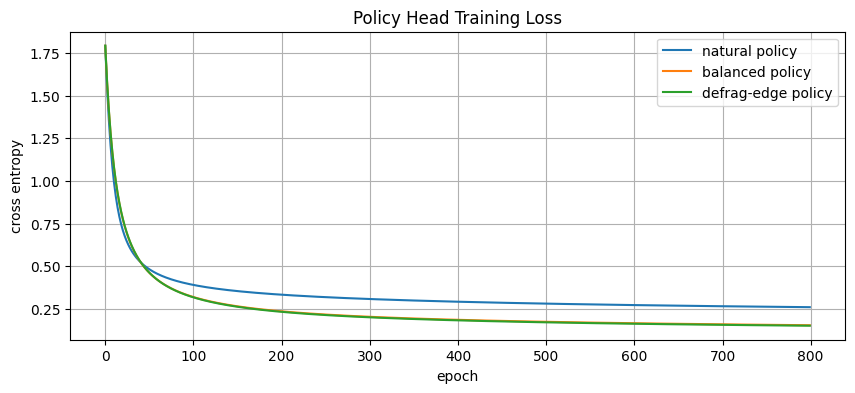

In [13]:

plt.figure(figsize=(10, 4))
plt.plot(loss_nat, label="natural policy")
plt.plot(loss_bal, label="balanced policy")
plt.plot(loss_def, label="defrag-edge policy")
plt.title("Policy Head Training Loss")
plt.xlabel("epoch")
plt.ylabel("cross entropy")
plt.legend()
plt.show()



## Practical readout

If the balanced or defrag-edge policy improves:
- action accuracy on the natural world
- retire recall
- grow_carry recall
- or promote precision without collapsing coverage

then the next runtime step is correct.

## What this means for the software stack

If this works, the stack becomes:

- **LLM**
  - proposal engine only

- **Shape runtime**
  - packet reader
  - trace logger

- **Bridge policy**
  - small trainable head
  - promote / hold / retire / grow-support

- **Value layer**
  - final readout only

That is the build path.

## Next move after v23

If v23 helps, v24 should:
- replace synthetic packets with real trace packets
- keep the same action targets
- keep edge-preserving defrag
- attach a local LLM only as a proposal source
